In this section we will be revisiting Countmin Sketch and constructing *range queries*. That is, we want to efficiently estimate counts between arbitrary intervals in the data.

In many applications, you might want more granularity than just the total amount of a certain instance. For instance, if you data on event times, it could be very desirable to have the ability to query your data for the approximate amount an event occurs within arbtirary stretches of time (e.g. how many flows were there to a certain IP address from 10:00 to 10:15).

There is however a more creative use of these range queries -- approximating text relationships while being more storage efficient. We will be using this to make simple approximations of text similarity. This portion of the assignment is loosely inspired by [this paper](https://users.umiacs.umd.edu/~hal3//docs/daume10distsim.pdf).


In [1]:
import json
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import mmh3
import numpy as np


In [2]:
FRANKPATH = str(Path.cwd() / "DataFiles" / "Frankenstein.txt")
with open(FRANKPATH, "r", encoding="utf-8", errors="ignore") as f:
    frankenstein = f.read()

# Hyperparameter: words per interval.
interval_words = 4000

clean_text = frankenstein.lower()
clean_text = re.sub(r"[^a-z\s]", " ", clean_text)
tokens = re.findall(r"[a-z]+", clean_text)

intervals = [
    tokens[i : i + interval_words]
    for i in range(0, len(tokens), interval_words)
]

print(f"Total words: {len(tokens):,}")
print(f"Interval size (words): {interval_words:,}")
print(f"Number of intervals: {len(intervals):,}")


Total words: 69,724
Interval size (words): 4,000
Number of intervals: 18


In [3]:
class CountMinSketch:
    """
    Count-Min Sketch for approximate frequency estimation.

    Parameters
    ----------
    epsilon : float
        Additive error tolerance as fraction of total stream length N.
        Estimate ≤ true_count + epsilon * N  with prob ≥ 1 - delta.
    delta : float
        Failure probability. Smaller → more rows → more accurate.

    Methods
    -------
    update(x, count=1)  : Record `count` occurrences of item x.
    query(x)            : Return estimated frequency of x.
    merge(other)        : Merge another compatible CMS into this one (in-place).
    """

    def __init__(self, epsilon: float = 0.01, delta: float = 0.05):
        self.epsilon = epsilon
        self.delta   = delta
        self.w = math.ceil(math.e / epsilon)
        self.d = math.ceil(math.log(1.0 / delta))
        self.table = np.zeros((self.d, self.w), dtype=np.int64)
        self.seeds = list(range(self.d))
        self.total = 0                         # total events inserted

    # ── internals ──────────────────────────────────────────────────────────

    def _cols(self, x: str):
        """Return column index for each row."""
        key = str(x)
        return [mmh3.hash(key, seed=s, signed=False) % self.w
                for s in self.seeds]

    # ── public API ─────────────────────────────────────────────────────────

    def update(self, x, count: int = 1):
        """Insert item x with optional weight count (default 1)."""
        for i, col in enumerate(self._cols(x)):
            self.table[i, col] += count
        self.total += count

    def query(self, x) -> int:
        """Return estimated frequency of x (always ≥ true count)."""
        return int(min(self.table[i, col] for i, col in enumerate(self._cols(x))))

    def merge(self, other: "CountMinSketch"):
        """Element-wise add another CMS (same d, w). Useful for distributed sketches."""
        assert self.d == other.d and self.w == other.w, "Incompatible sketch dimensions"
        self.table += other.table
        self.total += other.total

    # ── diagnostics ────────────────────────────────────────────────────────

    def error_bound(self) -> float:
        """Theoretical maximum additive error: ε · N."""
        return self.epsilon * self.total

    def memory_bytes(self) -> int:
        return self.table.nbytes

    def __repr__(self):
        return (f"CountMinSketch(ε={self.epsilon}, δ={self.delta}, "
                f"d={self.d}, w={self.w:,}, "
                f"N={self.total:,}, mem={self.memory_bytes()/1024:.1f} KB)")


# Shared sketch accuracy hyperparameters.
epsilon = 0.005
delta = 0.01


interval_sketches = []
for interval in intervals:
    cms = CountMinSketch(epsilon=epsilon, delta=delta)
    for tok in interval:
        cms.update(tok)
    interval_sketches.append(cms)



def query_interval(interval_idx: int, word: str) -> int:
    if interval_idx < 0 or interval_idx >= len(interval_sketches):
        raise IndexError("interval_idx out of range")
    return interval_sketches[interval_idx].query(word.lower())


def range_query(word: str, start_interval: int, end_interval: int) -> int:
    w = word.lower()
    total = 0
    for idx in range(start_interval, end_interval + 1):
        total += query_interval(idx, w)
    return int(total)





print("victor first 4000 words (interval 0):", range_query("victor", 0, 0))
print("fire words 12001-16000 (interval 3):", range_query("fire", 3, 3))
print("science first 20000 words (intervals 0-4):", range_query("science", 0, 4))


print("victor first 4000 words (interval 0):", range_query("victor", 0, 0))
print("fire words 12001-16000 (interval 3):", range_query("fire", 3, 3))
print("science first 20000 words (intervals 0-4):", range_query("science", 0, 4))


print("victor first 4000 words (interval 0):", range_query("victor", 0, 0))
print("fire words 12001-16000 (interval 3):", range_query("fire", 3, 3))
print("science first 20000 words (intervals 0-4):", range_query("science", 0, 4))


print("victor first 4000 words (interval 0):", range_query("victor", 0, 0))
print("fire words 12001-16000 (interval 3):", range_query("fire", 3, 3))
print("science first 20000 words (intervals 0-4):", range_query("science", 0, 4))


print("victor first 4000 words (interval 0):", range_query("victor", 0, 0))
print("fire words 12001-16000 (interval 3):", range_query("fire", 3, 3))
print("science first 20000 words (intervals 0-4):", range_query("science", 0, 4))

# Basic sanity check: common word should usually estimate higher than rare words.
for w in ["the", "monster"]:
    print(f"Total estimated count for '{w}': {range_query(w, 0, len(interval_sketches)-1)}")


#TODO: Run the following range queries:
#"victor" in the first 4000 words
#"fire" from the 12000th word to the 16000th word
#"science" for the first 20000 words


victor first 4000 words (interval 0): 5
fire words 12001-16000 (interval 3): 3
science first 20000 words (intervals 0-4): 24
victor first 4000 words (interval 0): 5
fire words 12001-16000 (interval 3): 3
science first 20000 words (intervals 0-4): 24
victor first 4000 words (interval 0): 5
fire words 12001-16000 (interval 3): 3
science first 20000 words (intervals 0-4): 24
victor first 4000 words (interval 0): 5
fire words 12001-16000 (interval 3): 3
science first 20000 words (intervals 0-4): 24
victor first 4000 words (interval 0): 5
fire words 12001-16000 (interval 3): 3
science first 20000 words (intervals 0-4): 24
Total estimated count for 'the': 3949
Total estimated count for 'monster': 54


Does your range query retain the same level of approximate accuracy if you try to do a range query on 8000 words (starting at a correct split point)? Why or why not?

If you were trying to keep the errors for this range query bounded (with 99\% probability) to within a certain $\epsilon$, what would you have to do when constructing the intervals?

There's also another problem with this approach. In order for our approximation to hold at all, our range query needs to neatly conform to the intervals we've specified.

How can we make a series of count min sketches that can handle any arbitrary interval? Dyadic intervals!

In [4]:
def build_dyadic_intervals(tokens, epsilon, delta):
    n = len(tokens)
    dyadic = {}
    if n == 0:
        return dyadic, n
    max_level = int(math.floor(math.log2(n)))
    for level in range(0, max_level + 1):
        block_len = 1 << level
        print("Level: " + str(level) + ", Interval Lengths: " + str(block_len))
        for start_word in range(0, n, block_len):
            end_word = start_word + block_len
            if end_word > n:
                continue
            cms = CountMinSketch(epsilon=epsilon, delta=delta)
            for token in tokens[start_word:end_word]:
                cms.update(token)
            dyadic[(level, start_word)] = cms
    return dyadic, n


# Use epsilon per sketch so that summing O(log n) dyadic blocks keeps additive error ~5% of interval mass.
RQEpsilon = 0.05 / (2 * max(1, int(np.ceil(np.log2(len(tokens))))))

dyadic_sketches, n_tokens = build_dyadic_intervals(
    tokens=tokens,
    epsilon=RQEpsilon,
    delta=delta,
)


def dyadic_range_query(word: str, start_word_idx: int, end_word_idx: int):
    if start_word_idx < 0 or end_word_idx >= n_tokens or start_word_idx > end_word_idx:
        raise ValueError("Invalid word-index range")

    i = start_word_idx
    segments = []

    while i <= end_word_idx:
        max_k = int(math.floor(math.log2(end_word_idx - i + 1)))
        k = max_k
        while k >= 0:
            block_len = 1 << k
            if (i % block_len == 0) and (i + block_len - 1 <= end_word_idx) and ((k, i) in dyadic_sketches):
                segments.append((k, i, block_len))
                i += block_len
                break
            k -= 1
        if k < 0:
            raise RuntimeError("Could not decompose range into dyadic blocks")

    estimate = sum(dyadic_sketches[(k, s)].query(word.lower()) for k, s, _ in segments)
    return {
        "word": word,
        "word_range": (start_word_idx, end_word_idx),
        "dyadic_segments": segments,
        "estimated_count": estimate,
    }


NFrankenstein = dyadic_range_query("frankenstein", 0, 9999)["estimated_count"]
NVictor = dyadic_range_query("victor", 39999, 60346)["estimated_count"]
NCreature = dyadic_range_query("creature", 28, 310)["estimated_count"]
print(NFrankenstein, NVictor, NCreature)


Level: 0, Interval Lengths: 1


Level: 1, Interval Lengths: 2


Level: 2, Interval Lengths: 4
Level: 3, Interval Lengths: 8


Level: 4, Interval Lengths: 16
Level: 5, Interval Lengths: 32
Level: 6, Interval Lengths: 64


Level: 7, Interval Lengths: 128
Level: 8, Interval Lengths: 256
Level: 9, Interval Lengths: 512


Level: 10, Interval Lengths: 1024
Level: 11, Interval Lengths: 2048
Level: 12, Interval Lengths: 4096
Level: 13, Interval Lengths: 8192
Level: 14, Interval Lengths: 16384
Level: 15, Interval Lengths: 32768
Level: 16, Interval Lengths: 65536


1 10 0


In [5]:
def estimate_from_anchor_positions(anchor_word: str, related_word: str, k: int = 20):
    if k < 0:
        raise ValueError("k must be non-negative")
    aw = anchor_word.lower()
    rw = related_word.lower()
    anchor_positions = [i for i, t in enumerate(tokens) if t == aw]
    n_tokens_local = len(tokens)
    per_anchor_estimates = []
    for idx in anchor_positions:
        start = min(idx + 1, n_tokens_local - 1)
        end = min(idx + k, n_tokens_local - 1)
        if start > end:
            est = 0
        else:
            est = dyadic_range_query(rw, start, end)["estimated_count"]
        per_anchor_estimates.append(
            {
                "anchor_idx": idx,
                "query_range": (start, end),
                "related_estimate": est,
            }
        )
    total_related_estimate = sum(item["related_estimate"] for item in per_anchor_estimates)
    nonzero = sum(1 for item in per_anchor_estimates if item["related_estimate"] > 0)
    return {
        "anchor_word": anchor_word,
        "related_word": related_word,
        "k": k,
        "num_anchor_positions": len(anchor_positions),
        "anchors_with_nonzero_related_estimate": nonzero,
        "total_related_estimate_over_all_anchor_windows": total_related_estimate,
        "per_anchor_estimates": per_anchor_estimates,
    }


ex1 = estimate_from_anchor_positions("frankenstein", "monster", k=20)
print({
    "anchor_word": ex1["anchor_word"],
    "related_word": ex1["related_word"],
    "k": ex1["k"],
    "num_anchor_positions": ex1["num_anchor_positions"],
    "anchors_with_nonzero_related_estimate": ex1["anchors_with_nonzero_related_estimate"],
    "total_related_estimate_over_all_anchor_windows": ex1["total_related_estimate_over_all_anchor_windows"],
})
print("First five per-anchor windows:", ex1["per_anchor_estimates"][:5])

ex2 = estimate_from_anchor_positions("victor", "creature", k=300)
print({
    "anchor_word": ex2["anchor_word"],
    "related_word": ex2["related_word"],
    "k": ex2["k"],
    "num_anchor_positions": ex2["num_anchor_positions"],
    "anchors_with_nonzero_related_estimate": ex2["anchors_with_nonzero_related_estimate"],
    "total_related_estimate_over_all_anchor_windows": ex2["total_related_estimate_over_all_anchor_windows"],
})


{'anchor_word': 'frankenstein', 'related_word': 'monster', 'k': 20, 'num_anchor_positions': 26, 'anchors_with_nonzero_related_estimate': 0, 'total_related_estimate_over_all_anchor_windows': 0}
First five per-anchor windows: [{'anchor_idx': 6133, 'query_range': (6134, 6153), 'related_estimate': 0}, {'anchor_idx': 10269, 'query_range': (10270, 10289), 'related_estimate': 0}, {'anchor_idx': 10545, 'query_range': (10546, 10565), 'related_estimate': 0}, {'anchor_idx': 13492, 'query_range': (13493, 13512), 'related_estimate': 0}, {'anchor_idx': 15026, 'query_range': (15027, 15046), 'related_estimate': 0}]
{'anchor_word': 'victor', 'related_word': 'creature', 'k': 300, 'num_anchor_positions': 28, 'anchors_with_nonzero_related_estimate': 4, 'total_related_estimate_over_all_anchor_windows': 4}


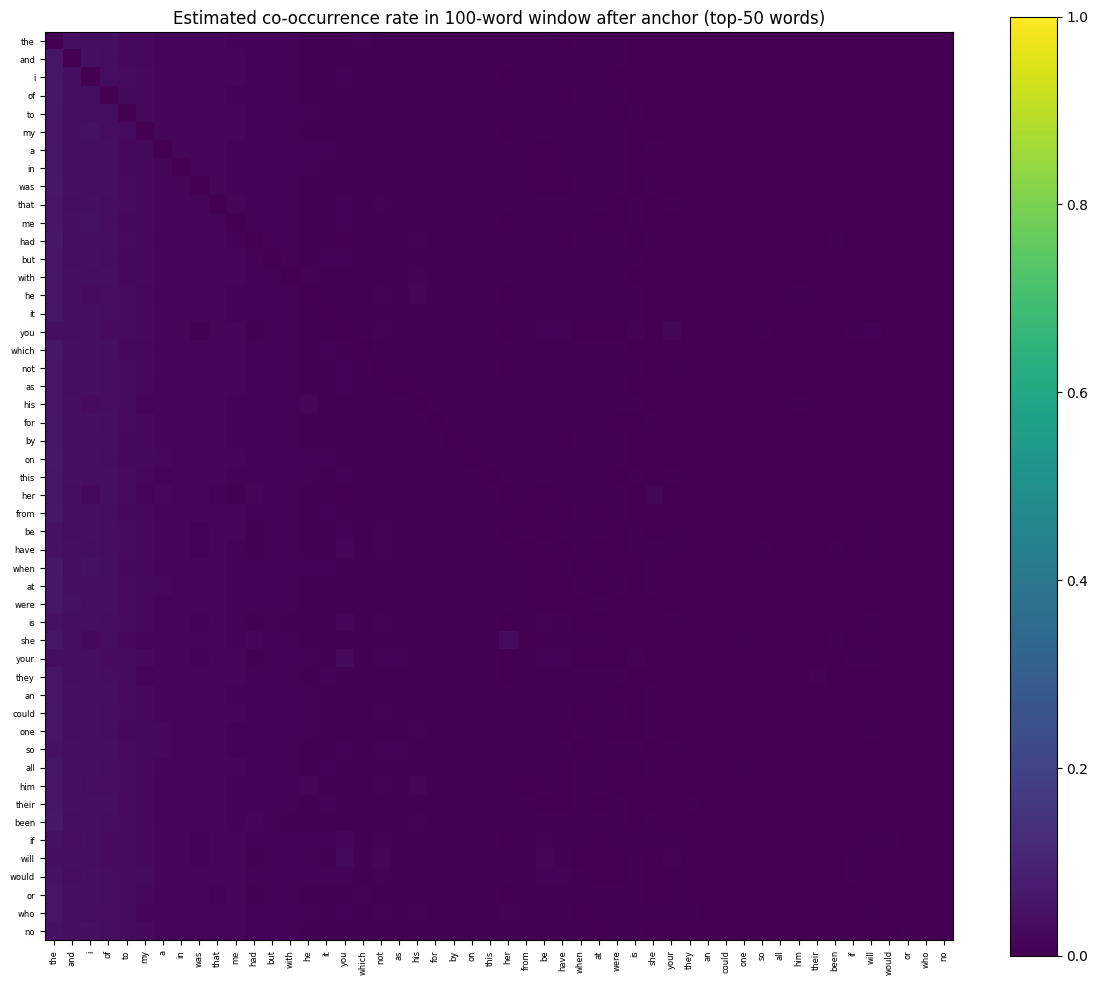

In [6]:
from collections import Counter

top50 = [w for w, _ in Counter(tokens).most_common(50)]
anchors = top50
others = top50
mat = np.zeros((len(anchors), len(others)))
for i, a in enumerate(anchors):
    na = max(1, tokens.count(a))
    for j, o in enumerate(others):
        if i == j:
            continue
        tot = estimate_from_anchor_positions(a, o, k=100)["total_related_estimate_over_all_anchor_windows"]
        mat[i, j] = tot / (na * 100.0)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(mat, vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(range(len(others)))
ax.set_xticklabels(others, rotation=90, fontsize=6)
ax.set_yticks(range(len(anchors)))
ax.set_yticklabels(anchors, fontsize=6)
ax.set_title("Estimated co-occurrence rate in 100-word window after anchor (top-50 words)")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


Your plot should be mostly prepositional words. A good sanity check but perhaps not very informative in terms of identifying relationships between words. What happens if we use a random selection of words from the book?

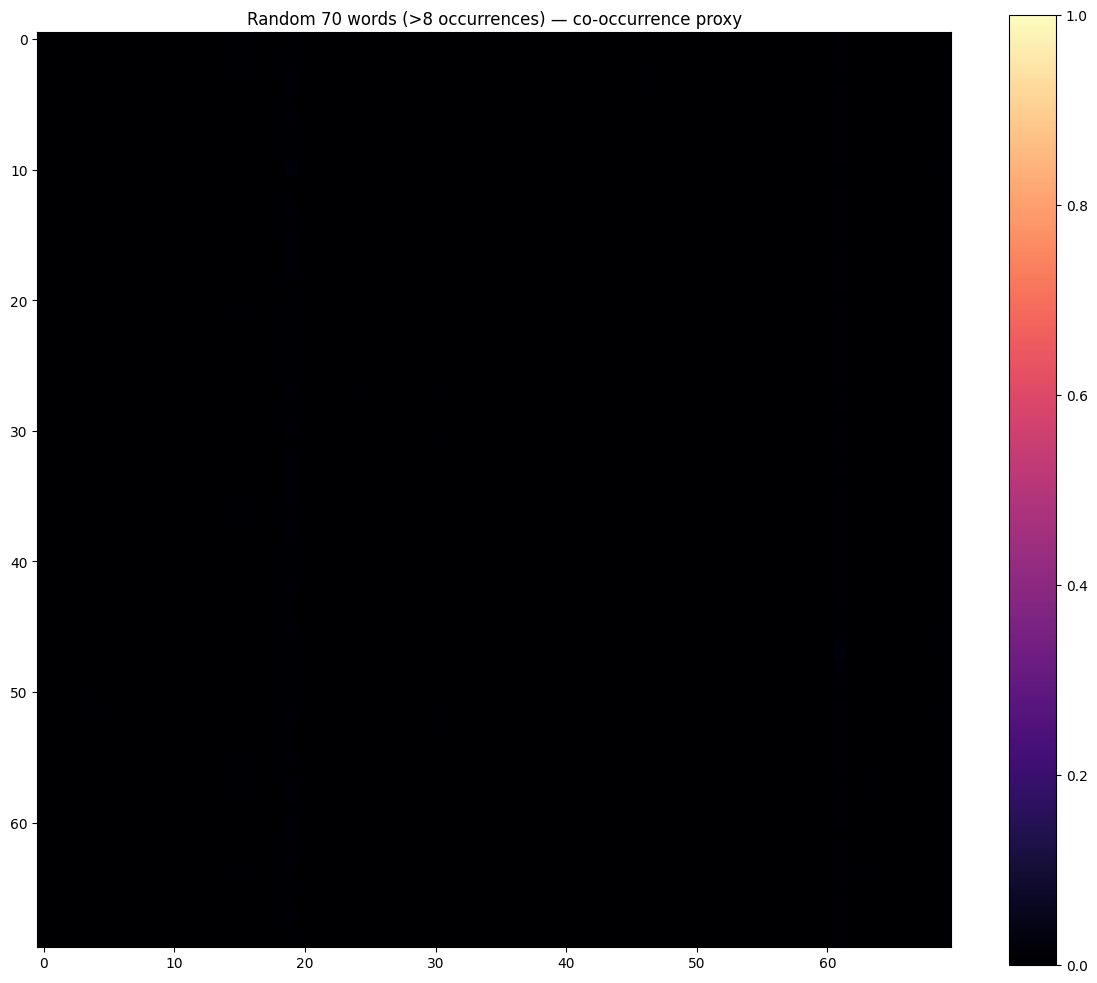

In [7]:
freq = Counter(tokens)
candidates = [w for w, c in freq.items() if c > 8]
rng = np.random.default_rng(808)
if len(candidates) < 70:
    words70 = candidates
else:
    words70 = list(rng.choice(candidates, size=70, replace=False))

anchors_r = words70
others_r = words70
mat_r = np.zeros((len(anchors_r), len(others_r)))
for i, a in enumerate(anchors_r):
    na = max(1, tokens.count(a))
    for j, o in enumerate(others_r):
        if i == j:
            continue
        tot = estimate_from_anchor_positions(a, o, k=100)["total_related_estimate_over_all_anchor_windows"]
        mat_r[i, j] = tot / (na * 100.0)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(mat_r, vmin=0, vmax=1, cmap="magma")
ax.set_title("Random 70 words (>8 occurrences) — co-occurrence proxy")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


# Export Your Results to JSON File

In [8]:
import json
json_output_path = "TextRangeQueries.json"
with open(json_output_path, "w", encoding="utf-8") as f:
    json.dump({
        "NFrankenstein":NFrankenstein,
        "NVictor": NVictor,
        "NCreature": NCreature,
        "RQEpsilon":RQEpsilon,
    }, f, indent=2)